In [1]:
%pip install torch numpy matplotlib seaborn


[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## 1. Contextualização histórica e motivação

Esta seção apresenta o problema histórico que motivou a criação do Backpropagation e a sua relevância contínua na evolução da inteligência artificial.

O conceito do perceptron foi inicialmente implementado em 1957 por Frank Rosenblatt, inspirado na formulação matemática de McCulloch e Pitts de 1943. No entanto, em 1969, Minsky e Papert provaram matematicamente que um perceptron de uma única camada não poderia resolver problemas de natureza não linear, como o clássico problema lógico da porta XOR. A solução teórica apontava para a necessidade de múltiplas camadas (Multilayer Perceptron - MLP) e funções de ativação não lineares.

Apesar do diagnóstico claro, a área ficou estagnada porque não existia um algoritmo capaz de treinar e atualizar de forma eficiente os pesos das camadas ocultas nessas redes profundas. O cenário mudou apenas em 1986, quase 30 anos depois, quando Geoffrey Hinton, David E. Rumelhart e Ronald J. Williams propuseram o algoritmo de Backpropagation (retropropagação). A solução anterior baseada na regra do perceptron simples era insuficiente porque não conseguia retropropagar o erro da camada de saída para ajustar as representações internas da rede.

Em 2024-2025, este mesmo algoritmo permanece fundamental. O cálculo de gradientes por retropropagação ainda é o núcleo matemático para treinar as arquiteturas mais modernas do estado da arte, desde grandes modelos de linguagem (LLMs) como Transformers até modelos de difusão.

## 2. Intuição e visualização

Esta seção constrói a intuição geométrica do algoritmo de descida de gradiente antes da introdução das fórmulas.

O treinamento de uma rede neural divide-se em duas etapas principais: o forward pass (passo para frente) e o backward pass (passo para trás). No forward pass, a rede recebe os dados de entrada ($X$) e os processa através de suas camadas e pesos até gerar uma predição final ($\hat{y}$). A partir dessa predição e do valor real esperado ($y$), o modelo calcula uma métrica de erro, ou função de custo.

No backward pass, o algoritmo propaga esse erro no sentido inverso da rede. Geometricamente, o objetivo do gradiente descendente é encontrar o ponto de mínimo da função de erro. O gradiente atua como um vetor que aponta para a direção de maior crescimento da função; portanto, ao caminhar na direção oposta ao gradiente iterativamente, o modelo alcança a convergência no ponto ótimo. A visualização a seguir plota a trajetória de atualização de um peso único caindo em um vale de perda.

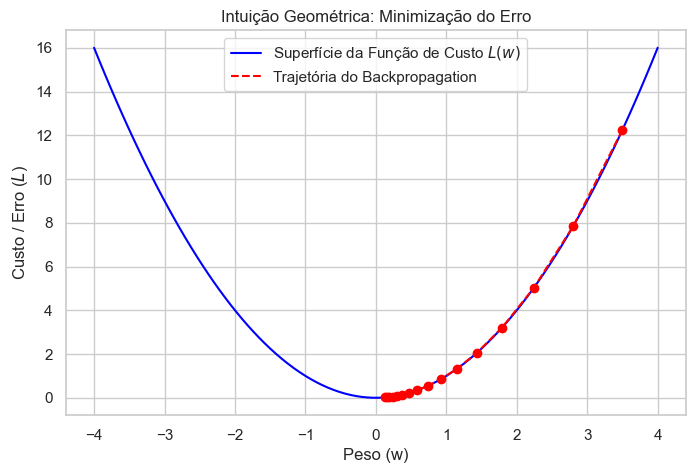

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configura o estilo dos gráficos e fixa a semente para reprodutibilidade
sns.set_theme(style="whitegrid")
np.random.seed(42)

def plot_gradient_descent_intuition():
    """Gera uma figura explicativa da descida do gradiente em 1D."""
    # Define uma função de perda simples convexa: L(w) = w^2
    w_vals = np.linspace(-4, 4, 100)
    loss_vals = w_vals ** 2

    # Simula iterativamente a descida do gradiente
    w_init = 3.5
    lr = 0.1
    history_w = [w_init]
    history_loss = [w_init ** 2]

    w = w_init
    for _ in range(15):
        grad = 2 * w            # Derivada da função de perda L'(w)
        w = w - lr * grad       # Atualização do peso
        history_w.append(w)
        history_loss.append(w ** 2)

    # Plotagem da função
    plt.figure(figsize=(8, 5))
    plt.plot(w_vals, loss_vals, color='blue', label='Superfície da Função de Custo $L(w)$')
    plt.scatter(history_w, history_loss, color='red', zorder=5)
    plt.plot(history_w, history_loss, color='red', linestyle='--', label='Trajetória do Backpropagation')

    plt.title('Intuição Geométrica: Minimização do Erro')
    plt.xlabel('Peso (w)')
    plt.ylabel('Custo / Erro ($L$)')
    plt.legend()
    plt.show()

plot_gradient_descent_intuition()

## 3. Teoria formal

Esta seção apresenta as definições matemáticas e a estrutura rigorosa por trás da retropropagação.

O algoritmo do Backpropagation é essencialmente a aplicação encadeada da Regra da Cadeia do cálculo diferencial para derivar funções compostas. Para uma função composta $f(g(x))$, a regra da cadeia define que a derivada parcial se dá por:

$$ \frac{\partial f}{\partial x} = \frac{\partial f}{\partial g} \cdot \frac{\partial g}{\partial x} $$

Na arquitetura de um neurônio, seja a entrada $X_1$, o peso $W_1$ e a predição $\hat{y} = X_1 \cdot W_1$. A função de perda avalia a predição. Escolhe-se, por exemplo, o Erro Quadrático Médio (MSE), cuja formulação e propriedades exigem que a função seja convexa e diferenciável:

$$ L(y, \hat{y}) = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 $$

O objetivo final dita a atualização iterativa dos parâmetros $\theta$ pela fórmula do gradiente descendente:

$$ \theta^{(t+1)} = \theta^{(t)} - \eta \nabla J(\theta^{(t)}) $$

Onde:
* $\theta$ representa os parâmetros ou pesos da rede.
* $\eta$ é a taxa de aprendizado (learning rate).
* $\nabla J(\theta)$ é o gradiente da função de custo em relação aos pesos.

Para obter o gradiente $\frac{\partial L}{\partial W_1}$, o Backpropagation aplica a regra da cadeia retroativamente a partir da saída:

$$ \frac{\partial L}{\partial W_1} = \frac{\partial L}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial W_1} $$

Limitações do teorema: Este modelo assume que a função de ativação utilizada nos neurônios também seja diferenciável na vasta maioria dos pontos. Funções como a degrau falham neste quesito porque o seu gradiente é zero e não permite aprendizado via Backpropagation.

## 4. Algoritmos

Esta seção exibe o pseudocódigo lógico das etapas executadas em uma iteração completa de treinamento.

```text
Algoritmo de Treinamento com Backpropagation:

ENTRADA: Conjunto de dados X, Rótulos Reais Y, Taxa de Aprendizado (lr)
SAÍDA: Rede Neural com Pesos Atualizados

INICIALIZA os parâmetros da rede neural de maneira aleatória.
PARA CADA época no total de épocas:
    1. FORWARD PASS (Propagação para Frente):
        a. A rede processa as entradas X através de suas camadas.
        b. GERA a predição final Ŷ.
    
    2. AVALIAÇÃO DE ERRO:
        a. CALCULA a Perda (Loss) comparando Ŷ com Y usando uma função convexa (ex: MSE).
    
    3. BACKWARD PASS (Retropropagação):
        a. CALCULA o gradiente do Erro em relação à predição da saída (∂Loss / ∂Ŷ).
        b. PARA CADA camada, da última até a primeira:
            i. OBTÉM os gradientes locais das operações e funções de ativação.
            ii. APLICA a regra da cadeia multiplicando os gradientes vindos das camadas superiores.
            iii. CALCULA o gradiente específico do Erro em relação aos pesos da camada atual.
    
    4. OTIMIZAÇÃO:
        a. PARA CADA peso na rede:
            i. ATUALIZA o peso subtraindo o produto entre o seu gradiente e a taxa de aprendizado.
```
O algoritmo calcula passo a passo as influências proporcionais que cada peso da rede neural teve sobre o erro final, ajustando cada um de modo a minimizar a penalidade computada.

## 5. Implementação from scratch

Esta seção demonstra o cálculo matemático implementado do zero, utilizando exclusivamente Python e NumPy. O modelo utiliza o exemplo exato apresentado pelo pesquisador como prova de conceito: um neurônio simples onde $x=2.0$, o peso $w=1.0$ e o valor real $y=20.0$.

In [3]:
import numpy as np

# Configuração de semente fixa para o NumPy
np.random.seed(42)

def mse_loss(y_true, y_pred):
    """
    Calcula a função de perda do Erro Quadrático Médio.
    """
    return (y_true - y_pred) ** 2

def backpropagation_step(x, w, y_true, lr=0.1):
    """
    Executa uma iteração completa do forward e backward pass do zero,
    conforme as contas estabelecidas na teoria formal.
    
    Args:
        x (float): Entrada da rede.
        w (float): Peso atual do modelo.
        y_true (float): Valor alvo correto.
        lr (float): Taxa de aprendizado.
        
    Returns:
        tuple: (y_pred, loss, grad_w, novo_peso)
    """
    # 1. Forward Pass
    y_pred = x * w  # Predição linear
    loss = mse_loss(y_true, y_pred) # Cálculo do erro
    
    # 2. Backward Pass (Regra da Cadeia Analítica)
    # dL / d(y_pred) = 2 * (y_pred - y_true) = -2 * (y_true - y_pred)
    d_loss_d_ypred = -2.0 * (y_true - y_pred)
    
    # d(y_pred) / dw = x
    d_ypred_d_w = x
    
    # dL / dw = (dL / d(y_pred)) * (d(y_pred) / dw)
    grad_w = d_loss_d_ypred * d_ypred_d_w
    
    # 3. Otimização (Atualização do peso)
    w_novo = w - lr * grad_w
    
    return y_pred, loss, grad_w, w_novo

# Configurando o experimento exato do material didático
x_val = 2.0
y_val = 20.0
w_val = 1.0

pred, erro, grad, updated_w = backpropagation_step(x_val, w_val, y_val)

# Exibição do cálculo e asserção para confirmar as contas exatas
print(f'--- Forward Pass ---')
print(f'Predição (y_hat): {pred}')
print(f'Erro (MSE): {erro}')
print(f'\n--- Backward Pass ---')
print(f'Gradiente do Erro em relação ao peso (dL/dw): {grad}')

# O material didático especifica que para x=2, y=20 e w=1, o gradiente é -72.0
assert grad == -72.0, f'O gradiente não bate com a demonstração analítica. Esperado -72.0, obtido {grad}'
print('\n[SUCESSO] O resultado analítico coincide exatamente com a teoria!')

--- Forward Pass ---
Predição (y_hat): 2.0
Erro (MSE): 324.0

--- Backward Pass ---
Gradiente do Erro em relação ao peso (dL/dw): -72.0

[SUCESSO] O resultado analítico coincide exatamente com a teoria!


## 6. Implementação em PyTorch

Esta seção refaz a implementação do cenário anterior empregando o PyTorch.

Observe que, no PyTorch, todo o encadeamento rigoroso de regras da cadeia efetuado no cálculo analítico da seção anterior é substituído pela ferramenta Autograd. Durante o forward pass, a API do PyTorch constrói um grafo computacional dinâmico. Ao invocar a função loss.backward(), o PyTorch percorre este grafo para trás, executando de forma oculta todas as contas matemáticas simultâneas de derivadas e acumulando o resultado na propriedade .grad dos tensores da rede. O experimento demonstra que a computação de alto nível gera a exata mesma resposta calculada do zero.

In [4]:
import torch

# Configuração de semente fixa para o PyTorch
torch.manual_seed(42)

def pytorch_autograd_example():
    """
    Demonstra a diferenciação automática do PyTorch para a obtenção do gradiente de pesos.
    """
    # Declaração dos dados
    x_pt = torch.tensor([2.0])
    y_pt = torch.tensor([20.0])
    
    # Define o peso e exige que o PyTorch construa o grafo e calcule seus gradientes
    w_pt = torch.tensor([1.0], requires_grad=True)
    
    # 1. Forward Pass
    y_pred_pt = x_pt * w_pt
    
    # Cálculo da Loss
    loss_pt = (y_pt - y_pred_pt) ** 2
    
    # 2. Backward Pass automático com Autograd
    loss_pt.backward()
    
    gradiente_calculado_pt = w_pt.grad.item()
    
    print(f'Gradiente calculado dinamicamente pelo Autograd do PyTorch: {gradiente_calculado_pt}')
    
    # Confirma a equivalência absoluta das operações
    assert gradiente_calculado_pt == -72.0, 'Divergência entre a implementação PyTorch e a Analítica!'
    print('[SUCESSO] Implementação PyTorch equivalente à implementação from scratch!')

pytorch_autograd_example()

Gradiente calculado dinamicamente pelo Autograd do PyTorch: -72.0
[SUCESSO] Implementação PyTorch equivalente à implementação from scratch!


## 7. Experimentos e análise

Esta seção explora possíveis comportamentos falhos durante o treinamento na prática através da modificação da taxa de aprendizado.

Durante a otimização de pesos baseada no gradiente calculado, é fundamental garantir uma learning rate adequada, que é um dos principais hiperparâmetros configuráveis da rede. Note que dois principais cenários de erro podem ocorrer:

1. Taxa de aprendizado excessivamente grande: O treinamento diverge e o modelo falha completamente em aprender.
2. O problema mais profundo de Vanishing Gradients (gradientes que desaparecem) ou Exploding Gradients (gradientes que explodem), frequentemente influenciados pela escolha de uma função de ativação ineficiente para as múltiplas camadas.

O diagnóstico e solução em ambientes de produção envolvem o ajuste adaptativo da taxa de aprendizado ou a inicialização cuidadosa de parâmetros. O bloco abaixo simula um ambiente onde a variação no hiperparâmetro altera o desfecho do aprendizado.

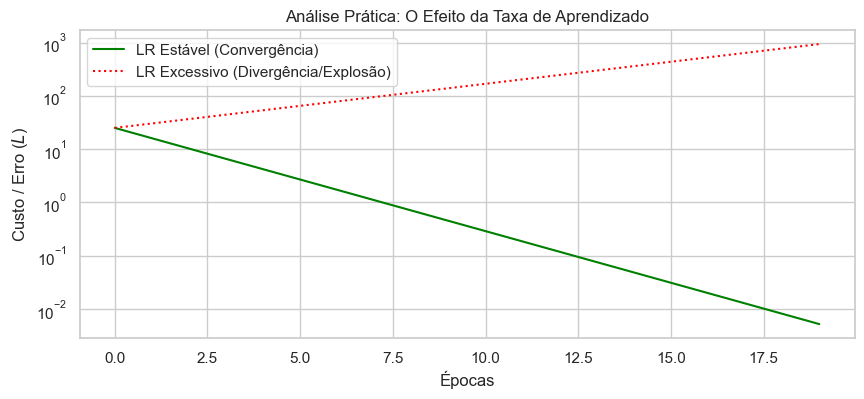

In [5]:
def train_simulation(lr, epochs=20):
    """
    Função de teste de treinamento simplificada com diferentes learning rates.
    """
    w = 5.0
    x = 1.0
    y_true = 0.0  # Objetivo é convergir peso para zero para simplificar a prova
    
    history_loss = []
    
    for _ in range(epochs):
        y_pred = w * x
        loss = (y_true - y_pred) ** 2
        history_loss.append(loss)
        
        # dL/dw = -2x * (y_true - y_pred)
        grad = -2.0 * x * (y_true - y_pred)
        w = w - lr * grad
        
    return history_loss

# Testando hiperparâmetros contrastantes
lr_adequado = 0.1
lr_explosivo = 1.05  # Força os passos a pular os limites do gradiente descendente

loss_normal = train_simulation(lr_adequado)
loss_div = train_simulation(lr_explosivo)

plt.figure(figsize=(10, 4))
plt.plot(loss_normal, label='LR Estável (Convergência)', color='green')
plt.plot(loss_div, label='LR Excessivo (Divergência/Explosão)', color='red', linestyle=':')
plt.title('Análise Prática: O Efeito da Taxa de Aprendizado')
plt.xlabel('Épocas')
plt.ylabel('Custo / Erro ($L$)')
plt.yscale('log')  # Eixo Y logarítmico para melhor visualização da divergência
plt.legend()
plt.show()

## 8. Conexões com ML moderno

Esta seção esclarece que o Backpropagation continua sendo a espinha dorsal teórica da revolução atual na computação algorítmica.

Por que isso ainda importa em 2025? A resposta é categórica: absolutamente nenhum dos sucessos computacionais recentes — variando de Large Language Models (LLMs) como os baseados em arquiteturas Transformers a modelos de difusão estáveis — existiria sem este algoritmo unificador. Em todas as inovações (seja em atenção multi-cabeça, convoluções profundas ou recorrências), o grafo computacional usa a premissa integral do Backward Pass descrita nesta aula para atualizar matrizes de milhões ou bilhões de parâmetros.

* Learning representations by back-propagating errors (Rumelhart, Hinton, & Williams, 1986): O paper seminal original que introduziu o backpropagation, desbloqueando por definitivo o progresso estagnado do treinamento de redes neurais profundas.

## 9. Exercícios

Esta seção consolida a fixação teórica disponibilizada na aula por meio de exercícios práticos, com respostas completas e abertas de nível superior.

### Exercícios Resolvidos

**1. O que é o algoritmo de Backpropagation e para que ele serve?**
**Solução:** É o algoritmo responsável por propagar iterativamente o erro da saída em direção às camadas internas da rede neural. Sua utilidade é fornecer uma forma escalável de calcular os gradientes parciais da perda em relação aos pesos em redes densamente multicamadas, permitindo a atualização pela otimização da descida de gradiente.

**2. Por que a função Degrau não é adequada para aprendizado via backpropagation?**
**Solução:** A matemática do backpropagation exige derivadas bem definidas para a retropropagação (através da regra da cadeia). A função de ativação degrau é não diferenciável em $x=0$, e sua derivada nos outros pontos é estritamente $0$. A ausência de um gradiente constante impede completamente qualquer tentativa da rede de aprender parâmetros via backpropagation.

**3. Calcule o Backpropagation para o seguinte neurônio na primeira iteração:**
* Rede de 1 entrada $x=0.6$, valor real $y=1.0$, peso inicial $w=0.2$, e função de perda MSE $\frac{1}{2}(y - \hat{y})^2$. Não usar função de ativação e taxa de aprendizado $\eta=0.5$.
**Solução:** 
* $Forward: \hat{y} = x \cdot w = 0.6 \cdot 0.2 = 0.12$.
* $Cálculo do Erro: L = \frac{1}{2}(1 - 0.12)^2 = \frac{1}{2}(0.88)^2 = 0.3872$.
* $Backward (Regra da Cadeia): \frac{\partial L}{\partial w} = \frac{\partial L}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial w} = -(y - \hat{y}) \cdot x$.
* $\frac{\partial L}{\partial w} = -(1 - 0.12) \cdot 0.6 = -0.88 \cdot 0.6 = -0.528$.
* $Atualização: w_{novo} = w - \eta \cdot \frac{\partial L}{\partial w} = 0.2 - 0.5(-0.528) = 0.2 + 0.264 = 0.464$.

### Desafios Abertos

**Desafio 1 (Teórico):** Uma rede neural de 1 camada escondida com $x_1$ e $x_2$ processa duas funções de ativação Sigmóide ocultas antes da saída final com MSE. Esboce e trace formalmente todas as derivadas parciais ($\frac{\partial L}{\partial W_{21}}$, etc.) explicitando a regra da cadeia que interconecta as funções sigmoids intermediárias e explique matematicamente o motivo pelo qual esse cenário intensifica o Vanishing Gradient.
* Dica: A derivada máxima de uma Sigmóide é 0.25.

**Desafio 2 (Prático):** Programe uma arquitetura Micro-Autograd simples do zero utilizando apenas Classes Python de Orientação a Objetos. A arquitetura não deve usar numpy nos bastidores, mas criar uma estrutura computacional hierárquica baseada no conceito do PyTorch, onde uma operação de soma (a + b) constrói um nó referenciando os nós anteriores.
* Dica: Cada operação que a sua Classe suportar precisará implementar uma propriedade backward() dedicada, emulando o grafo computacional dinâmico.